In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import xgboost as xgb
from sklearn import linear_model
from tqdm import tqdm

In [2]:
# ==========================
NUM_BOOST_ROUND = 75

# ==========================
# GÉNÉRATION DES DATES DE TRAIN/TEST
# ==========================

path = 'data/'

X_train = pd.read_csv(path + 'X_train.csv',index_col='ROW_ID')
# X_test = pd.read_csv(path + 'X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv(path + 'y_train.csv',index_col='ROW_ID')
y_train_bin = (y_train['target'] > 0).astype(int)
# sample_submission = pd.read_csv(path + 'sample_submission.csv',index_col='ROW_ID')
RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]

def standardize(x, axis=-1, keepdims=True):
    mean = x.mean(axis=axis, keepdims=keepdims)
    std = x.std(axis=axis, keepdims=keepdims)
    return (x - mean) / std

X_train[RET_features] = standardize(X_train[RET_features].values)
X_train[SIGNED_VOLUME_features] = standardize(X_train[SIGNED_VOLUME_features].values)

def FAR(row):
    ret = np.array(row['ret_ts'])
    vol = np.array(row['vol_ts'])
    return np.sum(ret * vol) / np.sum(np.abs(vol))



RET_features = [f'RET_{i}' for i in range(1,20)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,20)]
TURNOVER_features = ['AVG_DAILY_TURNOVER']
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
X_train['ret_ts'] = X_train[RET_features].values.tolist()
X_train['vol_ts'] = X_train[SIGNED_VOLUME_features].values.tolist()
X_train['FAR'] = X_train.apply(FAR, axis=1)
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features + ['FAR']
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]

In [3]:
date_train, date_test = train_test_split(X_train['TS'].unique(), test_size=0.1, random_state=42)

In [4]:
print(date_train.shape, date_test.shape)

(2495,) (278,)


In [23]:
# ==========================
# PARAMÈTRES XGBOOST
# ==========================
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "error",        # ou "auc" selon ton critère
    "booster": "gbtree",
    "max_depth": 4,                  # profondeur limitée (évite overfit)
    "min_child_weight": 3,           # contrôle la complexité
    "alpha": 1,                    # L1 regularization
    "random_state": 42,
    "tree_method": "approx",           # rapide et efficace
}

In [33]:
print(f"Nombre de dates uniques pour CV : {len(date_train)}")
# n_splits = 40
scores_xgb = {}
models_xgb = {}

splits = KFold(
    n_splits=100,
    random_state=0,
    shuffle=True
).split(date_train)

# # Pour chaque TS, associer une autre TS différente (shuffle sans égalité)
# shuffled_dates = np.random.permutation(dates)
# while np.any(shuffled_dates == dates):
#     shuffled_dates = np.random.permutation(dates)
# splits = zip(dates, shuffled_dates)


Nombre de dates uniques pour CV : 2495


In [34]:
for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = date_train[local_train_dates_ids]
    local_test_dates = date_train[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids,features]
    y_local_train = y_train.loc[local_train_ids,'target']
    X_local_test = X_train.loc[local_test_ids,features]
    y_local_test = y_train.loc[local_test_ids,'target']

    # Transformation en binaire
    y_local_train = (y_local_train > 0).astype(int)
    y_local_test = (y_local_test > 0).astype(int)

    # Conversion en DMatrix (format natif XGBoost)
    dtrain = xgb.DMatrix(X_local_train, label=y_local_train)
    dtest = xgb.DMatrix(X_local_test, label=y_local_test)

    # Entraînement
    model_xgb = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dtrain, "train"), (dtest, "test")],
        verbose_eval=False
    )

    # Prédiction
    y_local_pred_proba = model_xgb.predict(dtest)
    y_local_pred = (y_local_pred_proba > 0.5).astype(int)

    # Score
    score = accuracy_score(y_local_test, y_local_pred)
    scores_xgb[i] = (score)
    models_xgb[i] = model_xgb

    print(f"Fold {i+1} - Accuracy: {score * 100:.2f}%")


Fold 1 - Accuracy: 51.26%
Fold 2 - Accuracy: 49.35%
Fold 3 - Accuracy: 48.68%
Fold 4 - Accuracy: 50.09%
Fold 5 - Accuracy: 54.46%
Fold 6 - Accuracy: 55.02%
Fold 7 - Accuracy: 49.35%
Fold 8 - Accuracy: 51.69%
Fold 9 - Accuracy: 49.23%
Fold 10 - Accuracy: 47.08%
Fold 11 - Accuracy: 52.31%
Fold 12 - Accuracy: 49.85%
Fold 13 - Accuracy: 48.74%
Fold 14 - Accuracy: 51.82%
Fold 15 - Accuracy: 49.97%
Fold 16 - Accuracy: 50.09%
Fold 17 - Accuracy: 51.88%
Fold 18 - Accuracy: 47.32%
Fold 19 - Accuracy: 53.23%
Fold 20 - Accuracy: 50.22%
Fold 21 - Accuracy: 50.03%
Fold 22 - Accuracy: 49.29%
Fold 23 - Accuracy: 49.54%
Fold 24 - Accuracy: 48.86%
Fold 25 - Accuracy: 50.03%
Fold 26 - Accuracy: 52.25%
Fold 27 - Accuracy: 50.40%
Fold 28 - Accuracy: 56.18%
Fold 29 - Accuracy: 50.09%
Fold 30 - Accuracy: 54.03%
Fold 31 - Accuracy: 54.46%
Fold 32 - Accuracy: 52.80%
Fold 33 - Accuracy: 51.63%
Fold 34 - Accuracy: 52.86%
Fold 35 - Accuracy: 52.18%
Fold 36 - Accuracy: 49.35%
Fold 37 - Accuracy: 50.34%
Fold 38 - 

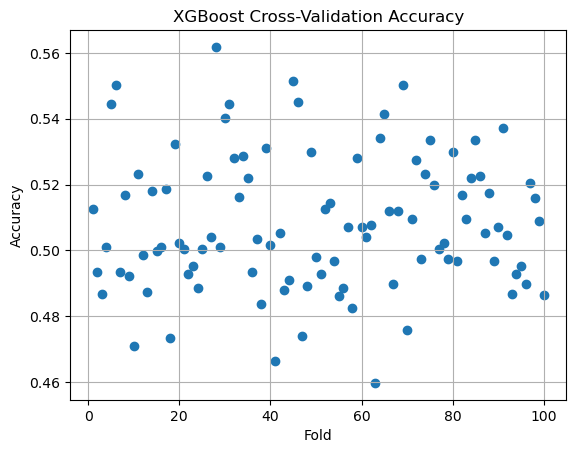

In [35]:
plt.scatter(range(1, len(scores_xgb) + 1), scores_xgb.values(), marker='o')

plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('XGBoost Cross-Validation Accuracy')
plt.grid()
plt.show()

In [ ]:
models_xgb_final = {
    i: model for i, model in models_xgb.items() if scores_xgb[i] > 0.5
}

In [41]:
accuracy_scores = []
weights = list(scores_xgb[models_xgb_final.keys()].values())

for i, date in enumerate(date_test):
    mask = X_train['TS'] == date
    X_date = X_train.loc[mask, features]
    y_date = y_train.loc[X_date.index, 'target']

    dtest = xgb.DMatrix(X_date)
    pred_agg = np.average([model.predict(dtest) for model in models_xgb_final],
                      axis=0, weights=weights)

    y_pred = (pred_agg > 0.5).astype(int)
    acc = accuracy_score((y_date > 0).astype(int), y_pred)
    accuracy_scores.append(acc)


AttributeError: 'list' object has no attribute 'keys'

In [38]:
np.array(accuracy_scores).mean()

np.float64(0.51743220807969)

In [ ]:
X_date = X_test_split.loc[mask, features]
y_date = y_test_bin.loc[X_date.index]

dtest = xgb.DMatrix(X_date)
pred_agg = np.average([model.predict(dtest) for model in models_xgb.values()],
                    axis=0, weights=weights)

y_pred = (pred_agg > 0.5).astype(int)
y_pred

In [ ]:
y_test_bin.loc[X_test_split.loc[mask].index]

In [ ]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))


# X_test_split_feat = X_test_split[features]
# dtest = xgb.DMatrix(X_test_split_feat)

# y_test_bin = (y_test > 0).astype(int)

# for model in models_xgb:
#     y_pred_proba = model.predict(dtest)
#     y_pred_proba = (y_pred_proba > 0.5).astype(int)
#     fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba)
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')

# plt.plot([0,1], [0,1], 'k--')
# plt.title("Courbes ROC comparées")
# plt.xlabel("Taux de faux positifs")
# plt.ylabel("Taux de vrais positifs")
# # plt.legend()
# plt.show()


In [ ]:
y_test_pred_proba = []

for index in tqdm(X_test_split.index):
    predictions = []
    # print(index)
    dtest = xgb.DMatrix(X_test_split.loc[[index], features])
    for i, model in models_xgb.items():
        if scores_xgb[i] > 0.45 :
            pred_proba = model.predict(dtest)
            predictions.append(pred_proba)
    # Affichage des prédictions
    y_test_pred_proba.append((np.mean(predictions) > 0.5).astype(int))



In [ ]:
y_test_pred_proba.count(1) / len(y_test_pred_proba)

In [ ]:
accuracy_score((y_test > 0).astype(int), y_test_pred_proba)